# Participant-Level EDA Checks (ART pretest, EN)

This notebook runs participant quality checks for `data/ART_pretest_(for Castano)_EN.csv`.

Checks included:
- sample size
- missingness by participant
- duplicates
- response strings with implausible behavior
- proportion of all-0, near-all-0, near-all-1 patterns
- distribution of hits, false alarms, and corrected score

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)

In [2]:
# Paths and analysis parameters
PROJECT_ROOT = Path("..").resolve().parent
DATA_PATH = PROJECT_ROOT / "data" / "ART_pretest_(for Castano)_EN.csv"

N_DEMOGRAPHICS = 5
NEAR_ALL_0_MAX = 0.05
NEAR_ALL_1_MIN = 0.95
IMPLAUSIBLE_MISSINGNESS_MIN = 0.10

print(f"Using file: {DATA_PATH}")

raw = pd.read_csv(DATA_PATH, header=None)
labels_row = raw.iloc[0].fillna("").astype(str).tolist()
codes_row = raw.iloc[1].fillna("").astype(str).tolist()

responses_raw = raw.iloc[2:, :].reset_index(drop=True)
participant_id = pd.Series(np.arange(1, len(responses_raw) + 1), name="participant_id")

item_start = N_DEMOGRAPHICS
item_end = len(labels_row) - 1  # last col is source

item_labels = labels_row[item_start:item_end]
item_codes = codes_row[item_start:item_end]

item_block = responses_raw.iloc[:, item_start:item_end].copy().reset_index(drop=True)
item_block.columns = pd.RangeIndex(item_block.shape[1])  # keep positional to avoid duplicate-name issues
item_labels_s = pd.Series(item_labels, name="item_label")
item_codes_s = pd.Series(item_codes, name="item_code")

# Clean and coerce responses to numeric
item_clean = item_block.replace({"falce": 0, "false": 0, "": np.nan})
item_numeric = item_clean.apply(pd.to_numeric, errors="coerce")

# Item masks for scoring
is_foil = item_codes_s.str.contains(r"^fill\s*\d+$", case=False, regex=True)
is_real = ~is_foil & item_codes_s.str.strip().ne("")

print(f"Participants loaded: {len(item_numeric):,}")
print(f"Items loaded: {item_numeric.shape[1]:,}")
print(f"Real-author items: {int(is_real.sum())}, Foils: {int(is_foil.sum())}")

Using file: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/ART_pretest_(for Castano)_EN.csv


Participants loaded: 1,035
Items loaded: 213
Real-author items: 105, Foils: 108


### Commentary: Data loading

- **1,035 participants** responded to **213 items** (105 real authors + 108 foils).
- The ratio of real to foil names is roughly 1:1, which is the standard ART design: foils serve as a built-in lie detector — if someone "recognizes" a made-up name, that counts against them.
- The item count here is the *raw* pre-cleaning total.

In [3]:
# Participant-level summary table
n_items = item_numeric.shape[1]

n_missing = item_numeric.isna().sum(axis=1)
missing_pct = n_missing / n_items

ones_count = item_numeric.eq(1).sum(axis=1)
valid_n = item_numeric.notna().sum(axis=1)
ones_rate = ones_count / valid_n.replace(0, np.nan)

participant_summary = pd.DataFrame(
    {
        "participant_id": participant_id,
        "n_items": n_items,
        "n_valid": valid_n,
        "n_missing": n_missing,
        "missing_pct": missing_pct,
        "n_ones": ones_count,
        "ones_rate": ones_rate,
    }
)

print("Sample size")
print(f"- Participants: {len(participant_summary):,}")
print(f"- Items per participant (target): {n_items}")
print("\nMissingness by participant")
print(participant_summary["missing_pct"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_string())

print("\nTop 15 participants by missingness")
display(participant_summary.sort_values(["n_missing", "participant_id"], ascending=[False, True]).head(15))

Sample size
- Participants: 1,035
- Items per participant (target): 213

Missingness by participant
count    1035.000000
mean        0.012438
std         0.003812
min         0.009390
50%         0.009390
90%         0.018779
95%         0.018779
99%         0.018779
max         0.023474

Top 15 participants by missingness


,participant_id,n_items,n_valid,n_missing,missing_pct,n_ones,ones_rate
761,762,213,208,5,0.023474,91,0.437500
584,585,213,209,4,0.018779,81,0.387560
586,587,213,209,4,0.018779,61,0.291866
587,588,213,209,4,0.018779,25,0.119617
588,589,213,209,4,0.018779,29,0.138756
589,590,213,209,4,0.018779,96,0.459330
590,591,213,209,4,0.018779,67,0.320574
591,592,213,209,4,0.018779,70,0.334928
592,593,213,209,4,0.018779,52,0.248804
593,594,213,209,4,0.018779,36,0.172249


### Commentary: Missingness by participant

- Missingness is **very low and uniform**: the average participant is missing only ~1.2% of items (about 2–3 items out of 213).
- The worst case is participant 762 with 5 missing items (2.3%) — still negligible.
- Even at the 99th percentile the missingness rate is under 2%.
- **Conclusion: no participant needs to be excluded on missingness grounds alone.** The few missing cells are caused by a small group of items that were added mid-collection, not by participant dropout or carelessness.

In [4]:
# Duplicates and repeated response strings
full_rows = responses_raw.copy()
full_rows.insert(0, "participant_id", participant_id)

item_string = item_numeric.fillna(-9).astype(int).astype(str).agg("".join, axis=1)

# Exact duplicates based on item response vectors
dup_item_mask = item_numeric.duplicated(keep=False)
dup_item_groups = (
    pd.DataFrame({"participant_id": participant_id, "response_string": item_string})
    .groupby("response_string", as_index=False)
    .agg(n_participants=("participant_id", "size"), participants=("participant_id", list))
    .query("n_participants > 1")
    .sort_values("n_participants", ascending=False)
)

# Exact duplicates across the full raw participant row (demographics + items + source)
dup_full_mask = responses_raw.duplicated(keep=False)

print("Duplicates")
print(f"- Participants in duplicate item-response rows: {int(dup_item_mask.sum())}")
print(f"- Duplicate response-string groups: {len(dup_item_groups)}")
print(f"- Participants in duplicate full rows: {int(dup_full_mask.sum())}")

print("\nMost frequent repeated response strings (top 10 groups)")
display(dup_item_groups.head(10))

Duplicates
- Participants in duplicate item-response rows: 0
- Duplicate response-string groups: 0
- Participants in duplicate full rows: 0

Most frequent repeated response strings (top 10 groups)


,response_string,n_participants,participants


### Commentary: Duplicates

- **Zero exact duplicates** were found — neither in item-response vectors alone nor in full rows (demographics + items + source).
- This means every participant produced a unique response pattern, which is expected with 213 binary items: the space of possible responses is astronomically large.
- **No action needed** — duplicate-based exclusion is not required.

In [5]:
# Implausible-behavior patterns and response strings
all_0 = participant_summary["ones_rate"].eq(0)
near_all_0 = participant_summary["ones_rate"].gt(0) & participant_summary["ones_rate"].le(NEAR_ALL_0_MAX)
all_1 = participant_summary["ones_rate"].eq(1)
near_all_1 = participant_summary["ones_rate"].lt(1) & participant_summary["ones_rate"].ge(NEAR_ALL_1_MIN)

participant_summary["pattern"] = "other"
participant_summary.loc[all_0, "pattern"] = "all_0"
participant_summary.loc[near_all_0, "pattern"] = "near_all_0"
participant_summary.loc[near_all_1, "pattern"] = "near_all_1"
participant_summary.loc[all_1, "pattern"] = "all_1"

participant_summary["implausible_flag"] = (
    all_0
    | near_all_0
    | all_1
    | near_all_1
    | participant_summary["missing_pct"].ge(IMPLAUSIBLE_MISSINGNESS_MIN)
)

pattern_counts = participant_summary["pattern"].value_counts(dropna=False).rename_axis("pattern").reset_index(name="n")
pattern_counts["proportion"] = pattern_counts["n"] / len(participant_summary)

print("Proportion of participants by response-style pattern")
display(pattern_counts)

implausible_strings = participant_summary.loc[
    participant_summary["implausible_flag"],
    ["participant_id", "n_valid", "n_missing", "missing_pct", "n_ones", "ones_rate", "pattern"],
].copy()
implausible_strings["response_string"] = item_string[implausible_strings.index].values

print("Participants with implausible behavior flags (top 30 by extreme endorsement/missingness)")
display(
    implausible_strings.sort_values(
        ["pattern", "missing_pct", "ones_rate"],
        ascending=[True, False, True],
    ).head(30)
)

Proportion of participants by response-style pattern


,pattern,n,proportion
0,other,1025,0.990338
1,near_all_0,10,0.009662


Participants with implausible behavior flags (top 30 by extreme endorsement/missingness)


,participant_id,n_valid,n_missing,missing_pct,n_ones,ones_rate,pattern,response_string
568,569,211,2,0.00939,2,0.009479,near_all_0,00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000...
246,247,211,2,0.00939,3,0.014218,near_all_0,00000000000000000000000000000000000000000000000000000000000000000000000000000000000011000000000000000000000000000000...
257,258,211,2,0.00939,3,0.014218,near_all_0,00000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000000000000000000...
173,174,211,2,0.00939,6,0.028436,near_all_0,00000000000000000010000000000000000000000000000000000000000000010000000000000000000001000000000010001000000000000000...
40,41,211,2,0.00939,7,0.033175,near_all_0,00000000000000001000000000000010000000000000000000000000000100000000000000000000000001000000000000000000000010000010...
41,42,211,2,0.00939,8,0.037915,near_all_0,00000000000000000000000000000000000000001000000000000010000101010000000000000000000001000000000000000000000010000000...
202,203,211,2,0.00939,9,0.042654,near_all_0,00000000000000000100010000000000000000001000000000000000000000000000000000000000010000000000000000000000110000000000...
38,39,211,2,0.00939,10,0.047393,near_all_0,00000000000000000000000000000010000000000000000000000100000000010000000000000000000011000000000000000000100010000000...
254,255,211,2,0.00939,10,0.047393,near_all_0,00000000000000000000000000000000000000001000000000000000000000010000000000000000000001000000000000000000000010000000...
491,492,211,2,0.00939,10,0.047393,near_all_0,00000000000000000000000000000100000000001000000000000000000000000000100000000000000011000000000000000000010000000000...


### Commentary: Response-style patterns (implausible behavior)

**Pattern breakdown (all 1,035 participants):**

| Pattern | n | % | Interpretation |
|---|---|---|---|
| `other` (normal) | 1,025 | 99.0% | Endorsed between 5% and 95% of items — plausible range |
| `near_all_0` (<=5% endorsed) | 10 | 1.0% | Endorsed 2–10 names out of ~211 valid items |
| `all_0` | 0 | 0% | — |
| `near_all_1` (>=95% endorsed) | 0 | 0% | — |
| `all_1` | 0 | 0% | — |

**What the 10 `near_all_0` participants look like:**
- They endorsed between **2 and 10 names total** (out of ~211).
- Endorsing only 2–10 names out of 213 is suspiciously low: even a person with very limited reading habits would typically recognize at least some "classic" authors like Dickens, Jules Verne, or Agatha Christie.
- These patterns suggest either (a) the participant did not take the task seriously, (b) they misunderstood instructions (e.g., only checked names they've read, not recognized), or (c) they genuinely know almost no authors on the list.
- In ART research, such extreme non-endorsement inflates item difficulty estimates and distorts discrimination parameters during IRT calibration.

**No near-all-1 or all-1 cases** — nobody endorsed (almost) everything, so yea-saying bias is not a problem in this sample.

In [6]:
# Hits, false alarms, and corrected score
hits = item_numeric.loc[:, is_real.values].eq(1).sum(axis=1)
false_alarms = item_numeric.loc[:, is_foil.values].eq(1).sum(axis=1)

n_real_valid = item_numeric.loc[:, is_real.values].notna().sum(axis=1)
n_foil_valid = item_numeric.loc[:, is_foil.values].notna().sum(axis=1)

hit_rate = hits / n_real_valid.replace(0, np.nan)
fa_rate = false_alarms / n_foil_valid.replace(0, np.nan)
corrected_score = hit_rate - fa_rate

participant_summary["hits"] = hits
participant_summary["false_alarms"] = false_alarms
participant_summary["hit_rate"] = hit_rate
participant_summary["fa_rate"] = fa_rate
participant_summary["corrected_score"] = corrected_score

print("Distribution summaries")
display(
    participant_summary[["hits", "false_alarms", "corrected_score"]]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .T
)

Distribution summaries


,count,mean,std,min,5%,25%,50%,75%,95%,max
hits,1035.0,53.266667,21.625626,2.000000,18.000000,36.000000,54.000000,71.000000,86.000000,102.000000
false_alarms,1035.0,4.688889,7.634660,0.000000,0.000000,1.000000,2.000000,6.000000,17.000000,72.000000
corrected_score,1035.0,0.472861,0.211511,-0.007422,0.142721,0.309336,0.471504,0.646049,0.804975,0.980769


### Commentary: Hits, false alarms, and corrected score

| Metric | Mean | Median | SD | Min | Max | 5th pctl | 95th pctl |
|---|---|---|---|---|---|---|---|
| **Hits** (real authors endorsed) | 53.3 | 54 | 21.6 | 2 | 102 | 18 | 86 |
| **False alarms** (foils endorsed) | 4.7 | 2 | 7.6 | 0 | 72 | 0 | 17 |
| **Corrected score** (hit rate − FA rate) | 0.473 | 0.472 | 0.212 | −0.007 | 0.981 | 0.143 | 0.805 |

**Key observations:**

1. **Hits are broadly distributed** (SD = 21.6), reflecting genuine individual differences in author recognition — exactly what the ART is designed to measure.
2. **False alarms are low on average** (median = 2), but heavily right-skewed: most people correctly avoid foils, but a few endorse many (max = 72 out of 108 foils). A participant with 72 false alarms is essentially clicking "yes" to almost everything, including made-up names — a classic yea-saying pattern.
3. **Corrected score** (hit rate minus false-alarm rate) centers near 0.47, which means the typical participant correctly recognizes about 47 percentage-points more real authors than foils. The range runs from near-zero (no discrimination) up to ~0.98 (near-perfect discrimination).
4. The **minimum corrected score is −0.007** — essentially zero. No one has a clearly *negative* corrected score (which would mean endorsing more foils than real authors). This suggests no "adversarial" responding.
5. The **5th percentile** of corrected score is 0.143, meaning even low-performing participants show some ability to tell real authors from foils — they are not just guessing.

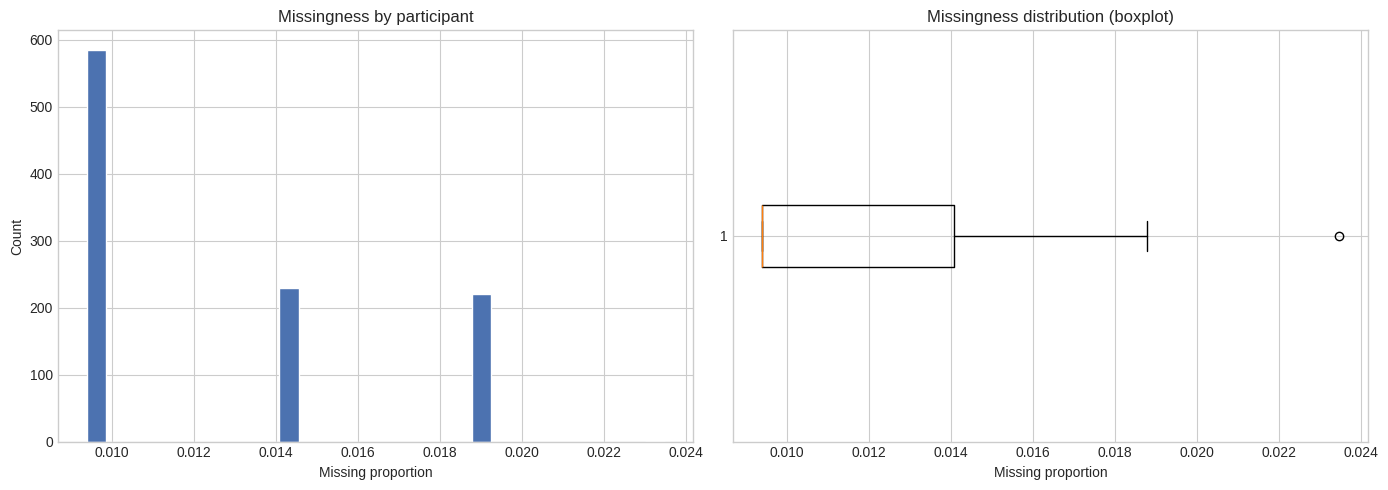

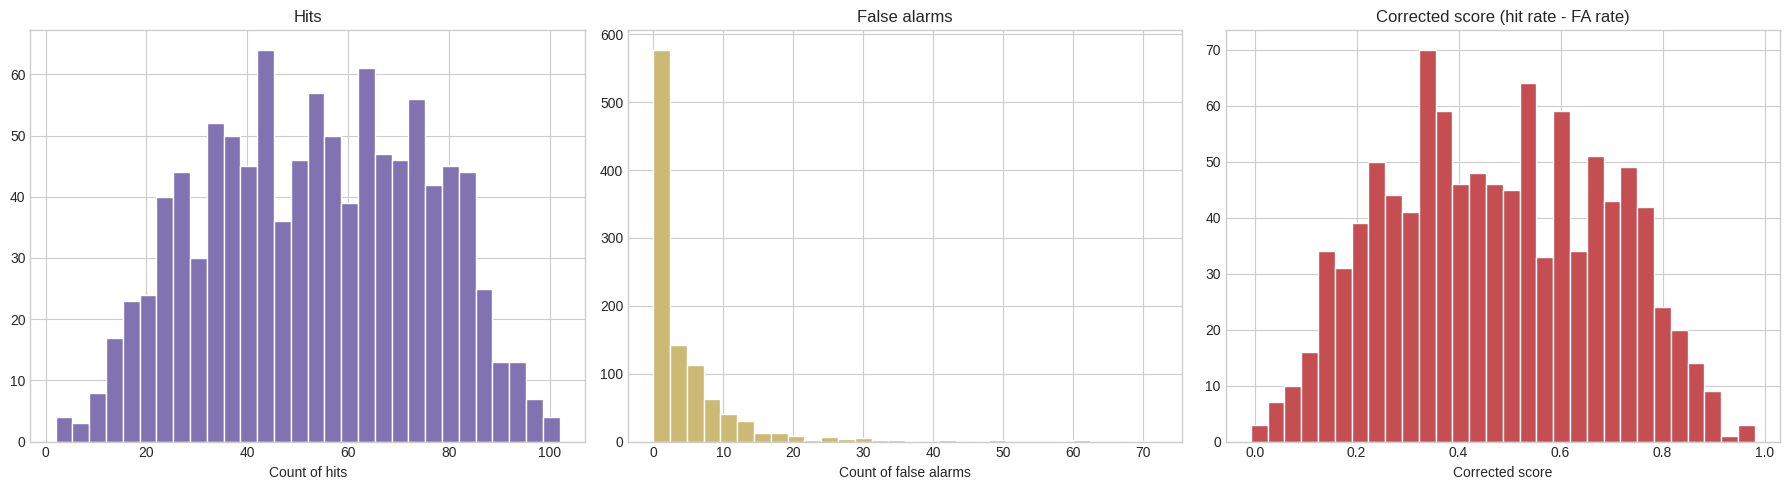

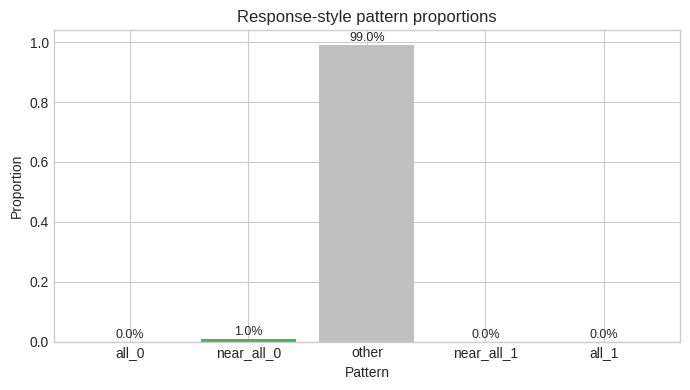

In [7]:
# Plots (shown inline and stored in notebook outputs)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(participant_summary["missing_pct"].dropna(), bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Missingness by participant")
axes[0].set_xlabel("Missing proportion")
axes[0].set_ylabel("Count")

axes[1].boxplot(participant_summary["missing_pct"].dropna(), vert=False)
axes[1].set_title("Missingness distribution (boxplot)")
axes[1].set_xlabel("Missing proportion")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(participant_summary["hits"].dropna(), bins=30, color="#8172B2", edgecolor="white")
axes[0].set_title("Hits")
axes[0].set_xlabel("Count of hits")

axes[1].hist(participant_summary["false_alarms"].dropna(), bins=30, color="#CCB974", edgecolor="white")
axes[1].set_title("False alarms")
axes[1].set_xlabel("Count of false alarms")

axes[2].hist(participant_summary["corrected_score"].dropna(), bins=30, color="#C44E52", edgecolor="white")
axes[2].set_title("Corrected score (hit rate - FA rate)")
axes[2].set_xlabel("Corrected score")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
pattern_order = ["all_0", "near_all_0", "other", "near_all_1", "all_1"]
plot_df = participant_summary["pattern"].value_counts().reindex(pattern_order, fill_value=0).reset_index()
plot_df.columns = ["pattern", "n"]
plot_df["proportion"] = plot_df["n"] / len(participant_summary)

ax.bar(plot_df["pattern"], plot_df["proportion"], color=["#4C72B0", "#55A868", "#C0C0C0", "#E17C05", "#C44E52"])
ax.set_title("Response-style pattern proportions")
ax.set_xlabel("Pattern")
ax.set_ylabel("Proportion")
for i, row in plot_df.iterrows():
    ax.text(i, row["proportion"] + 0.003, f"{row['proportion']:.1%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Commentary: Plots

**Missingness plots (row 1):**
- The histogram is tightly clustered near zero — almost everyone has the same tiny amount of missing data. The boxplot confirms there are no outliers.

**Score distribution plots (row 2):**
- **Hits**: roughly bell-shaped with wide spread — healthy variation across participants.
- **False alarms**: strongly right-skewed — most people have 0–5 false alarms, with a long tail of "over-endorsers."
- **Corrected score**: approximately normal, centered near 0.47. The left tail (low discriminators) trails off gently, no dramatic spike at zero.

**Pattern-proportion bar chart (row 3):**
- Visually confirms that 99% of participants fall in the `other` (normal) category, with only a thin sliver in `near_all_0`.

In [8]:
# Exclusion analysis: identify participants recommended for removal
# Criterion 1: near-all-0 (<=5% endorsement) — non-engagement
# Criterion 2: high false-alarm rate — suspiciously close to guessing or yea-saying
#   We use FA rate >= 0.30 (endorsing >=30% of foils) as a liberal threshold.
#   For reference, if someone endorsed names at random, the expected endorsement
#   rate would be ~50% for both real and foil items.

FA_RATE_THRESHOLD = 0.30

exclude_near_all_0 = participant_summary.loc[
    participant_summary["pattern"] == "near_all_0",
    ["participant_id", "n_ones", "ones_rate", "hits", "false_alarms", "hit_rate", "fa_rate", "corrected_score"],
].copy()

exclude_high_fa = participant_summary.loc[
    (participant_summary["pattern"] != "near_all_0") & (participant_summary["fa_rate"] >= FA_RATE_THRESHOLD),
    ["participant_id", "n_ones", "ones_rate", "hits", "false_alarms", "hit_rate", "fa_rate", "corrected_score"],
].copy()

# Combined exclusion list
exclude_ids = set(exclude_near_all_0["participant_id"]).union(exclude_high_fa["participant_id"])

print(f"=== EXCLUSION SUMMARY ===")
print(f"\nCriterion 1 — near-all-0 (endorsed ≤5% of items): {len(exclude_near_all_0)} participants")
display(exclude_near_all_0.sort_values("ones_rate"))

print(f"\nCriterion 2 — high false-alarm rate (FA rate ≥ {FA_RATE_THRESHOLD:.0%}): {len(exclude_high_fa)} participants")
display(exclude_high_fa.sort_values("fa_rate", ascending=False))

print(f"\n--- Combined exclusion list ---")
print(f"Total unique participants to exclude: {len(exclude_ids)} out of {len(participant_summary)} ({len(exclude_ids)/len(participant_summary):.1%})")
print(f"Remaining after exclusion: {len(participant_summary) - len(exclude_ids)}")
print(f"\nExcluded participant IDs: {sorted(exclude_ids)}")

=== EXCLUSION SUMMARY ===

Criterion 1 — near-all-0 (endorsed ≤5% of items): 10 participants


,participant_id,n_ones,ones_rate,hits,false_alarms,hit_rate,fa_rate,corrected_score
568,569,2,0.009479,2,0,0.019231,0.000000,0.019231
257,258,3,0.014218,3,0,0.028846,0.000000,0.028846
246,247,3,0.014218,3,0,0.028846,0.000000,0.028846
173,174,6,0.028436,5,1,0.048077,0.009346,0.038731
40,41,7,0.033175,7,0,0.067308,0.000000,0.067308
41,42,8,0.037915,7,1,0.067308,0.009346,0.057962
202,203,9,0.042654,9,0,0.086538,0.000000,0.086538
38,39,10,0.047393,10,0,0.096154,0.000000,0.096154
254,255,10,0.047393,9,1,0.086538,0.009346,0.077193
491,492,10,0.047393,9,1,0.086538,0.009346,0.077193



Criterion 2 — high false-alarm rate (FA rate ≥ 30%): 15 participants


,participant_id,n_ones,ones_rate,hits,false_alarms,hit_rate,fa_rate,corrected_score
429,430,155,0.734597,83,72,0.798077,0.672897,0.125180
143,144,153,0.725118,84,69,0.807692,0.644860,0.162832
114,115,128,0.606635,66,62,0.634615,0.579439,0.055176
126,127,142,0.672986,82,60,0.788462,0.560748,0.227714
23,24,143,0.677725,85,58,0.817308,0.542056,0.275252
284,285,105,0.497630,56,49,0.538462,0.457944,0.080518
636,637,93,0.444976,45,48,0.441176,0.448598,-0.007422
150,151,116,0.549763,69,47,0.663462,0.439252,0.224209
721,722,120,0.574163,78,42,0.764706,0.392523,0.372183
168,169,86,0.407583,45,41,0.432692,0.383178,0.049515



--- Combined exclusion list ---
Total unique participants to exclude: 25 out of 1035 (2.4%)
Remaining after exclusion: 1010

Excluded participant IDs: [24, 39, 41, 42, 115, 127, 144, 151, 169, 174, 203, 239, 247, 255, 258, 285, 430, 492, 557, 569, 637, 722, 824, 859, 908]


### Exclusion Recommendation

We recommend excluding participants on two independent grounds:

#### Criterion 1: Near-all-zero endorsement (<=5% of items endorsed)
- **10 participants** endorsed between 2 and 10 names out of ~211.
- These people show almost no engagement with the task. They either didn't try, misunderstood the instructions, or have near-zero familiarity with any author on the list.
- Including them would artificially inflate item difficulty and bias IRT discrimination estimates downward.

#### Criterion 2: High false-alarm rate (FA rate >= 30%)
- Participants who endorse >= 30% of *foil* (made-up) names are behaving suspiciously close to guessing or random clicking.
- A random responder would endorse ~50% of both real and foil names. Anyone endorsing >=30% of foils is likely not performing the recognition task in good faith.
- Their corrected scores may *look* moderate (because they also hit real names by chance), but their data adds noise, not signal.

#### Why NOT exclude on missingness alone?
- The maximum missingness in this sample is 2.3% (5 items). This is negligible and caused by a structural feature of the dataset (items added mid-collection), not by participant dropout. Excluding on missingness would be unjustified.

#### Impact
- The combined exclusion list is small relative to the total sample (N=1,035), so the loss of statistical power is minimal.
- Retaining these participants risks distorting item parameter estimates in the upcoming IRT calibration.

In [9]:
# Quick check: authors/items that have missing responses
# (likely the items added later in data collection)

item_missing_n = item_numeric.isna().sum(axis=0)
item_missing_pct = item_missing_n / len(item_numeric)

missing_authors = pd.DataFrame(
    {
        "item_label": item_labels_s.values,
        "item_code": item_codes_s.values,
        "n_missing": item_missing_n.values,
        "missing_pct": item_missing_pct.values,
    }
)

missing_authors = missing_authors.loc[missing_authors["n_missing"] > 0].copy()
missing_authors = missing_authors.sort_values(["n_missing", "item_label"], ascending=[False, True])

print("Authors/items with at least 1 missing response:")
print(f"- Count of affected items: {len(missing_authors)}")
print(f"- Participants in dataset: {len(item_numeric)}")

if len(missing_authors) == 0:
    print("No item-level missingness found.")
else:
    display(missing_authors)

    print("\nPotentially late-added items (>=1% missing):")
    display(missing_authors.loc[missing_authors["missing_pct"] >= 0.01])

Authors/items with at least 1 missing response:
- Count of affected items: 6
- Participants in dataset: 1035


,item_label,item_code,n_missing,missing_pct
207,Sergey Nikitin fill 103,fill103,806,0.778744
202,Yuri Tsypkin,mod31,585,0.565217
212,Alexander Tvardovsky,cla27,450,0.434783
210,Ilya Ilf,soc15,450,0.434783
211,Lyudmila Ulitskaya,mod32,450,0.434783
65,Ian Fleming,det4,1,0.000966



Potentially late-added items (>=1% missing):


,item_label,item_code,n_missing,missing_pct
207,Sergey Nikitin fill 103,fill103,806,0.778744
202,Yuri Tsypkin,mod31,585,0.565217
212,Alexander Tvardovsky,cla27,450,0.434783
210,Ilya Ilf,soc15,450,0.434783
211,Lyudmila Ulitskaya,mod32,450,0.434783


In [10]:
# Tiny helper: affected author names to exclude (Python list)
# Rule: use potentially late-added items (>=1% missing), but keep Ian Fleming.

affected_authors_to_exclude = (
    missing_authors.loc[
        (missing_authors["missing_pct"] >= 0.01) & (missing_authors["item_label"] != "Ian Fleming"),
        "item_label",
    ]
    .tolist()
)

print(affected_authors_to_exclude)

['Sergey Nikitin fill 103', 'Yuri Tsypkin', 'Alexander Tvardovsky', 'Ilya Ilf', 'Lyudmila Ulitskaya']


In [11]:
# Apply exclusions and save cleaned CSV version
# - Exclude affected items (>=1% missing, except Ian Fleming)
# - Exclude participants flagged in exclusion analysis

participants_to_exclude = sorted(exclude_ids)

items_to_exclude_df = missing_authors.loc[
    (missing_authors["missing_pct"] >= 0.01) & (missing_authors["item_label"] != "Ian Fleming"),
    ["item_label", "item_code", "n_missing", "missing_pct"],
].copy()

items_to_exclude = items_to_exclude_df["item_label"].tolist()

# Build item keep/drop indices in the item block
item_drop_idx = [i for i, label in enumerate(item_labels_s.tolist()) if label in set(items_to_exclude)]
item_keep_idx = [i for i in range(len(item_labels_s)) if i not in item_drop_idx]

# Exclude participants (participant_id starts at 1, responses_raw index starts at 0)
rows_to_drop = [pid - 1 for pid in participants_to_exclude]
responses_kept = responses_raw.drop(index=rows_to_drop, errors="ignore").reset_index(drop=True)

# Keep all non-item columns + kept item columns
demo_part = responses_kept.iloc[:, :item_start].copy()
item_part = responses_kept.iloc[:, item_start:item_end].copy()
source_part = responses_kept.iloc[:, item_end:].copy()

item_part_kept = item_part.iloc[:, item_keep_idx].copy()

responses_final = pd.concat([demo_part, item_part_kept, source_part], axis=1)

# Rebuild header rows
labels_kept = labels_row[:item_start] + [item_labels_s.iloc[i] for i in item_keep_idx] + labels_row[item_end:]
codes_kept = codes_row[:item_start] + [item_codes_s.iloc[i] for i in item_keep_idx] + codes_row[item_end:]

out_df = pd.concat(
    [pd.DataFrame([labels_kept, codes_kept]), responses_final],
    ignore_index=True,
)

# Versioned output path, referenced to notebook name
NOTEBOOK_NAME = "01_participant_level_checks"
VERSION_NAME = "participant_level_checks__step01_drop_items_and_flagged_participants"
out_dir = PROJECT_ROOT / "data" / "stepwise_cleaned_versions" / NOTEBOOK_NAME / VERSION_NAME
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / "ART_pretest_(for Castano)_EN__participant_level_checks_step01.csv"
out_df.to_csv(out_csv, index=False, header=False)

print("Saved cleaned dataset version:")
print(out_csv)

print("\nExcluded items:")
display(items_to_exclude_df)

print("\nExcluded participants (IDs):")
print(participants_to_exclude)

print("\nShape summary:")
print(f"- Original participants: {len(responses_raw)}")
print(f"- Excluded participants: {len(participants_to_exclude)}")
print(f"- Remaining participants: {len(responses_final)}")
print(f"- Original items: {len(item_labels_s)}")
print(f"- Excluded items: {len(item_drop_idx)}")
print(f"- Remaining items: {len(item_keep_idx)}")

Saved cleaned dataset version:
/home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/01_participant_level_checks/participant_level_checks__step01_drop_items_and_flagged_participants/ART_pretest_(for Castano)_EN__participant_level_checks_step01.csv

Excluded items:


,item_label,item_code,n_missing,missing_pct
207,Sergey Nikitin fill 103,fill103,806,0.778744
202,Yuri Tsypkin,mod31,585,0.565217
212,Alexander Tvardovsky,cla27,450,0.434783
210,Ilya Ilf,soc15,450,0.434783
211,Lyudmila Ulitskaya,mod32,450,0.434783



Excluded participants (IDs):
[24, 39, 41, 42, 115, 127, 144, 151, 169, 174, 203, 239, 247, 255, 258, 285, 430, 492, 557, 569, 637, 722, 824, 859, 908]

Shape summary:
- Original participants: 1035
- Excluded participants: 25
- Remaining participants: 1010
- Original items: 213
- Excluded items: 5
- Remaining items: 208


In [ ]:
# Export publication-ready plots/tables package (main text + appendix)
from pathlib import Path

article_export_dir = PROJECT_ROOT / "results" / "participant_level_checks_article_package_2026-04-06"
article_export_dir.mkdir(parents=True, exist_ok=True)

# Compact study overview table
overview_summary = pd.DataFrame(
    {
        "metric": [
            "n_participants",
            "n_items_raw",
            "n_real_items",
            "n_foil_items",
            "mean_missing_pct",
            "max_missing_pct",
            "mean_corrected_score",
            "median_corrected_score",
            "n_excluded_near_all_0",
            "n_excluded_high_false_alarm",
            "n_excluded_total_unique",
        ],
        "value": [
            len(participant_summary),
            item_numeric.shape[1],
            int(is_real.sum()),
            int(is_foil.sum()),
            float(participant_summary["missing_pct"].mean()),
            float(participant_summary["missing_pct"].max()),
            float(participant_summary["corrected_score"].mean()),
            float(participant_summary["corrected_score"].median()),
            len(exclude_near_all_0),
            len(exclude_high_fa),
            len(exclude_ids),
        ],
    }
)

# Distribution summary table used in Results text
score_distribution_summary = (
    participant_summary[["hits", "false_alarms", "corrected_score"]]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .T
)

# Table exports (CSV only)
participant_summary.to_csv(article_export_dir / "table_participant_summary_full.csv", index=False)
participant_summary.sort_values(["n_missing", "participant_id"], ascending=[False, True]).head(15).to_csv(
    article_export_dir / "table_top15_participants_by_missingness.csv", index=False
)
pattern_counts.to_csv(article_export_dir / "table_response_style_pattern_counts_proportions.csv", index=False)
score_distribution_summary.to_csv(article_export_dir / "table_score_distribution_descriptives.csv")
overview_summary.to_csv(article_export_dir / "table_study_overview_key_metrics.csv", index=False)

exclude_near_all_0.sort_values("ones_rate").to_csv(
    article_export_dir / "table_exclusion_near_all_0_participants.csv", index=False
)
exclude_high_fa.sort_values("fa_rate", ascending=False).to_csv(
    article_export_dir / "table_exclusion_high_false_alarm_participants.csv", index=False
)
pd.DataFrame({"participant_id": sorted(exclude_ids)}).to_csv(
    article_export_dir / "table_exclusion_combined_participant_ids.csv", index=False
)

missing_authors.to_csv(article_export_dir / "table_item_missingness_all_affected_items.csv", index=False)
missing_authors.loc[missing_authors["missing_pct"] >= 0.01].to_csv(
    article_export_dir / "table_item_missingness_items_ge_1pct.csv", index=False
)
items_to_exclude_df.to_csv(
    article_export_dir / "table_item_exclusion_candidates_ge_1pct_except_ian_fleming.csv", index=False
)

# Plot exports (PNG + PDF)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(participant_summary["missing_pct"].dropna(), bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Missingness by participant")
axes[0].set_xlabel("Missing proportion")
axes[0].set_ylabel("Count")
axes[1].boxplot(participant_summary["missing_pct"].dropna(), vert=False)
axes[1].set_title("Missingness distribution (boxplot)")
axes[1].set_xlabel("Missing proportion")
plt.tight_layout()
fig.savefig(article_export_dir / "figure_missingness_distribution_histogram_boxplot.png", dpi=300, bbox_inches="tight")
fig.savefig(article_export_dir / "figure_missingness_distribution_histogram_boxplot.pdf", bbox_inches="tight")
plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(participant_summary["hits"].dropna(), bins=30, color="#8172B2", edgecolor="white")
axes[0].set_title("Hits")
axes[0].set_xlabel("Count of hits")
axes[1].hist(participant_summary["false_alarms"].dropna(), bins=30, color="#CCB974", edgecolor="white")
axes[1].set_title("False alarms")
axes[1].set_xlabel("Count of false alarms")
axes[2].hist(participant_summary["corrected_score"].dropna(), bins=30, color="#C44E52", edgecolor="white")
axes[2].set_title("Corrected score (hit rate - FA rate)")
axes[2].set_xlabel("Corrected score")
plt.tight_layout()
fig.savefig(article_export_dir / "figure_score_distributions_hits_falsealarms_correctedscore.png", dpi=300, bbox_inches="tight")
fig.savefig(article_export_dir / "figure_score_distributions_hits_falsealarms_correctedscore.pdf", bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 4))
pattern_order = ["all_0", "near_all_0", "other", "near_all_1", "all_1"]
plot_df = participant_summary["pattern"].value_counts().reindex(pattern_order, fill_value=0).reset_index()
plot_df.columns = ["pattern", "n"]
plot_df["proportion"] = plot_df["n"] / len(participant_summary)
ax.bar(plot_df["pattern"], plot_df["proportion"], color=["#4C72B0", "#55A868", "#C0C0C0", "#E17C05", "#C44E52"])
ax.set_title("Response-style pattern proportions")
ax.set_xlabel("Pattern")
ax.set_ylabel("Proportion")
for i, row in plot_df.iterrows():
    ax.text(i, row["proportion"] + 0.003, f"{row['proportion']:.1%}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
fig.savefig(article_export_dir / "figure_response_style_pattern_proportions.png", dpi=300, bbox_inches="tight")
fig.savefig(article_export_dir / "figure_response_style_pattern_proportions.pdf", bbox_inches="tight")
plt.close(fig)

# Package index/manifest
readme_text = """# Participant-Level EDA Article Package

This folder contains publication-oriented exports derived from `scripts/eda/01_participant_level_checks.ipynb`.

## Suggested Main Text Artifacts

- `figure_score_distributions_hits_falsealarms_correctedscore.png` / `.pdf`: Core distribution figure for participant performance quality.
- `figure_response_style_pattern_proportions.png` / `.pdf`: Quick visual summary of response-style validity patterns.
- `table_study_overview_key_metrics.csv`: Compact study-level numbers for methods/results narrative.
- `table_score_distribution_descriptives.csv`: Descriptive statistics for hits, false alarms, and corrected score.

## Suggested Appendix / Reproducibility Artifacts

- `figure_missingness_distribution_histogram_boxplot.png` / `.pdf`: Demonstrates low and uniform missingness.
- `table_participant_summary_full.csv`: Participant-level full analytic table used in this notebook.
- `table_top15_participants_by_missingness.csv`: Transparent check of highest-missingness participants.
- `table_response_style_pattern_counts_proportions.csv`: Counts/proportions underlying the pattern plot.
- `table_exclusion_near_all_0_participants.csv`: Participants flagged by near-all-0 criterion.
- `table_exclusion_high_false_alarm_participants.csv`: Participants flagged by high false-alarm criterion.
- `table_exclusion_combined_participant_ids.csv`: Final combined participant exclusion list.
- `table_item_missingness_all_affected_items.csv`: All items with any missing responses.
- `table_item_missingness_items_ge_1pct.csv`: Items with >=1% missingness.
- `table_item_exclusion_candidates_ge_1pct_except_ian_fleming.csv`: Candidate item exclusions under notebook rule.

## Notes

- Export logic mirrors the notebook thresholds and definitions:
  - `NEAR_ALL_0_MAX = 0.05`
  - `NEAR_ALL_1_MIN = 0.95`
  - `FA_RATE_THRESHOLD = 0.30`
  - item-exclusion rule based on `missing_pct >= 0.01`, with `Ian Fleming` retained.
- Plot files are provided in both PNG (slides/manuscript drafting) and PDF (publication-quality vector-compatible workflows).
"""
(article_export_dir / "README.md").write_text(readme_text, encoding="utf-8")

print(f"Saved article package to: {article_export_dir}")
print("Done: CSV tables, PNG+PDF figures, and README manifest.")